In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "6"
DEVICE='cuda:0'

In [2]:
import sys
sys.path.append(os.path.realpath('../../'))

In [3]:
from transformers import AutoModelForQuestionAnswering, AutoTokenizer, pipeline

model_name = "deepset/roberta-large-squad2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
# model = AutoModelForQuestionAnswering.from_pretrained(model_name, cache_dir="/mount/arbeitsdaten/asr-2/vaethdk/resources/weights/").to(DEVICE)

/mount/arbeitsdaten/asr-2/vaethdk/virtualenvs/cts_en/lib64/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import torch

In [5]:
nlp = pipeline('question-answering', model=model_name, tokenizer=model_name, device=DEVICE, cache_dir="/mount/arbeitsdaten/asr-2/vaethdk/resources/weights/")

In [6]:
QA_input = {
    'question': 'What do we need?',
    'context': 'Computers are neccessary for daily life.'
}
res = nlp(QA_input)

In [7]:
res

{'score': 0.9104044437408447, 'start': 0, 'end': 9, 'answer': 'Computers'}

In [6]:
from data.dataset import GraphDataset, ReimburseGraphDataset, DataAugmentationLevel, DialogNode, NodeType

In [7]:
human_data_train = ReimburseGraphDataset('en/reimburse/train_graph.json', 'en/reimburse/train_answers.json', False, augmentation=DataAugmentationLevel.NONE, resource_dir="../../resources/")
human_data_test = ReimburseGraphDataset('en/reimburse/test_graph.json', 'en/reimburse/test_answers.json', False, augmentation=DataAugmentationLevel.NONE, resource_dir="../../resources/")
generated_data_train_v1 = ReimburseGraphDataset('en/reimburse/train_graph.json', 'en/reimburse/generated/chatgpt/train_answers.json', False, augmentation=DataAugmentationLevel.ARTIFICIAL_ONLY, augmentation_path="en/reimburse/generated/chatgpt/train_questions_v1.json", resource_dir="../../resources/")
generated_data_train_v2 = ReimburseGraphDataset('en/reimburse/train_graph.json', 'en/reimburse/generated/chatgpt/train_answers.json', False, augmentation=DataAugmentationLevel.ARTIFICIAL_ONLY, augmentation_path="en/reimburse/generated/chatgpt/train_questions_v2.json", resource_dir="../../resources/")
generated_data_train_v3 = ReimburseGraphDataset('en/reimburse/train_graph.json', 'en/reimburse/generated/chatgpt/train_answers.json', False, augmentation=DataAugmentationLevel.ARTIFICIAL_ONLY, augmentation_path="en/reimburse/generated/chatgpt/train_questions_v3.json", resource_dir="../../resources/")

- not using synonyms
===== Dataset Statistics =====
- files:  en/reimburse/train_graph.json en/reimburse/train_answers.json
- synonyms: False
- depth: 20  - degree: 13
- answers: 81
- questions: 279
- loaded original data: True
- loaded generated data: False
- question limit: 0  - maximum loaded:  7
- answer limit: 0  - maximum loaded:  1
- not using synonyms
===== Dataset Statistics =====
- files:  en/reimburse/test_graph.json en/reimburse/test_answers.json
- synonyms: False
- depth: 20  - degree: 13
- answers: 81
- questions: 173
- loaded original data: True
- loaded generated data: False
- question limit: 0  - maximum loaded:  4
- answer limit: 0  - maximum loaded:  1
- Loading questions from  ../../resources/en/reimburse/generated/chatgpt/train_questions_v1.json
- not using synonyms
===== Dataset Statistics =====
- files:  en/reimburse/train_graph.json en/reimburse/generated/chatgpt/train_answers.json
- synonyms: False
- depth: 20  - degree: 13
- answers: 81
- questions: 800
- load

In [8]:
datasets = {
    # "Human Train": human_data_train,
    # "Human Test": human_data_test,
    "Generated V1": generated_data_train_v1,
    # "Generated V1 Ling": generated_data_train_v1_ling,
    "Generated V2": generated_data_train_v2,
    # "Generated V2 Ling": generated_data_train_v2_ling,
    "Generated V3": generated_data_train_v3,
    # "Generated V3 Ling": generated_data_train_v3_ling,
}

In [9]:
from tqdm.auto import tqdm
import torch

scores = {}

for dataset_name in datasets:
    dataset = datasets[dataset_name]
    scores[dataset_name] = []
    print(dataset_name, "#questions:", len(dataset.question_list))

    for question in tqdm(dataset.question_list):
        if question.parent.node_type == NodeType.INFO:
            # check if question is answerable by node text
            qa_pair = {
                'question': question.text,
                'context':  question.parent.text
            }
            res = nlp(qa_pair)
            score = res['score']
            scores[dataset_name].append(qa_pair | {"score": score})

    torch.save(scores[dataset_name], f"llama_{dataset_name}_qa_scores.pt")

Generated V1 #questions: 800


  1%|          | 9/800 [00:02<02:10,  6.06it/s]/mount/arbeitsdaten/asr-2/vaethdk/virtualenvs/cts_en/lib64/python3.10/site-packages/transformers/pipelines/base.py:1081: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
100%|██████████| 800/800 [00:19<00:00, 40.68it/s]


Generated V2 #questions: 800


100%|██████████| 800/800 [00:17<00:00, 46.43it/s]


Generated V3 #questions: 827


100%|██████████| 827/827 [00:17<00:00, 46.74it/s]


In [10]:
import seaborn as sns
import pandas

In [11]:
ds_scores = []
for dataset_name in datasets:
    data = torch.load(f"llama_{dataset_name}_qa_scores.pt")
    dataset = datasets[dataset_name]
    scores = [item['score'] for item in data]
    print(dataset_name, "#questions:", len(dataset.question_list), "#scores:", len(scores))
    for score in scores:
        ds_scores.append({"source": dataset_name, "score": score})
df = pandas.DataFrame(ds_scores)

Generated V1 #questions: 800 #scores: 800
Generated V2 #questions: 800 #scores: 800
Generated V3 #questions: 827 #scores: 827


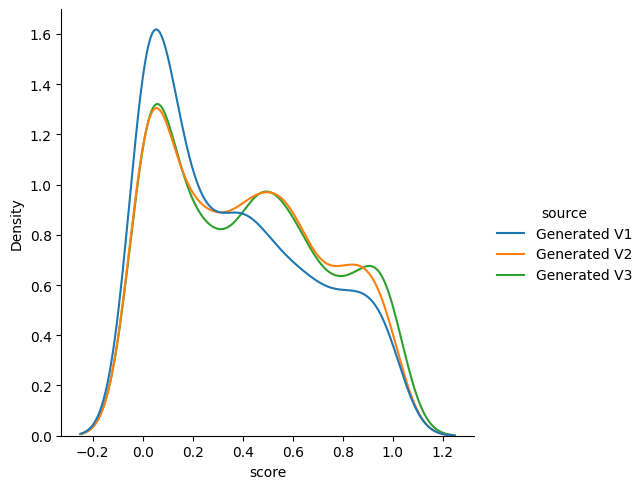

In [12]:
sns.displot(df.reset_index(drop=True), x="score", kind="kde", hue='source', common_norm=False)

In [18]:
# Extract some bad example qa pairs
bad_questions = {}

for dataset_name in datasets:
    data = torch.load(f"llama_{dataset_name}_qa_scores.pt")
    print(dataset_name, "#questions:", len(dataset.question_list), "#scores:", len(scores))
    bad_questions[dataset_name] = []
    for item in data:
        if item["score"] < 0.0001:
            bad_questions[dataset_name].append(item)

        # if len(bad_questions[dataset_name]) > 5:
        #     break

Human Train #questions: 416 #scores: 416
Human Test #questions: 416 #scores: 416
Generated V1 #questions: 416 #scores: 416
Generated V2 #questions: 416 #scores: 416
Generated V3 #questions: 416 #scores: 416


In [19]:
bad_questions['Human Train']

[{'question': 'Can I book first class?',
  'context': 'Booking a "Business"  class ticket is allowed on flights which last more than 10 uninterrupted hours. Otherwise, only the cheapest flight class is reimbursable. A seat reservation is not reimbursable.',
  'score': 1.056544761013356e-06},
 {'question': 'Can I book regional transportation?',
  'context': "You can book train tickets yourself (through the DB website, at their counter / ticket machine) or through the university's partner travel agency (Tel. +123456789). You can find contact information for the partner travel agency here.",
  'score': 3.0357628929778002e-05},
 {'question': 'What is counted as an ancillary cost?',
  'context': 'Incidental costs are, e.g.,: Insurances Visa fees \n Conference meals \n Parking fees \n Oversized baggage fees \n Conference fees \n Credit card fees \n Cloakroom fees \n Entrance costs \n Postage costs \n Vaccinations',
  'score': 2.633099484228296e-06},
 {'question': 'What trainings are offered 

In [20]:
bad_questions['Generated V3']

[{'question': 'What is the cheapest flight class that is reimbursable for flights under 10 uninterrupted hours?',
  'context': 'Booking a "Business"  class ticket is allowed on flights which last more than 10 uninterrupted hours. Otherwise, only the cheapest flight class is reimbursable. A seat reservation is not reimbursable.',
  'score': 6.661098450422287e-05},
 {'question': 'Can I skip asking my supervisor for an intracity trip?',
  'context': "Verbal permission is required from your supervisor for an intracity business trip. Please don't forget to get this. Written permission is not necessary",
  'score': 6.588458927581087e-05},
 {'question': 'What is the role of RKI in providing travel warnings and restrictions related to COVID-19?',
  'context': 'Please check the current COVID-19 travel warnings travel restrictions from the foreign ministry and the RKI. Business trips to high risk areas or virus variation areas are not generally not allowed. In In extreme cases, authorization can